In [1]:
from torchvision import models
import torch.nn as nn
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import json
import timm
from tqdm import tqdm
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[0]
sys.path.append(str(ROOT))

from Utils.project_utils import *
import Utils.constants as c
from Utils.transforms import *
from Utils.MushroomDataset import *
from Utils.dataLoaders import *

In [3]:
PROJECT_ROOT = get_project_root()
CLASSES_DIR = PROJECT_ROOT / "Classes"
DATA_DIR = PROJECT_ROOT / "Data"

device = get_device()

Using device: mps


In [4]:
SPLIT_DIR = DATA_DIR / "splits"

train = pd.read_csv(SPLIT_DIR / "train.csv")
val = pd.read_csv(SPLIT_DIR / "val.csv")
test = pd.read_csv(SPLIT_DIR / "test.csv")

with open(SPLIT_DIR / "class_to_idx.json", "r") as f:
    train_class_to_idx = json.load(f)

#### 3rd Model - Swin Transformer Tiny

##### Build Data Loaders

In [5]:
train_tfms_mild = get_train_tfms_mild()
train_tfms_strong = get_train_tfms_strong()
val_tfms = get_val_tfms()

In [6]:
CLASSES = sorted(train["class"].unique().tolist())

In [7]:
loaders = make_loaders(
    train,
    val,
    test,
    train_tfms_mild,
    train_tfms_strong,
    val_tfms,
    train_class_to_idx,
    CLASSES,
    c.BATCH_SIZE,
    c.NUM_WORKERS,
    device,
)

loaders

{'train_loader_mild': <torch.utils.data.dataloader.DataLoader at 0x313ad04d0>,
 'train_loader_strong': <torch.utils.data.dataloader.DataLoader at 0x3131e8590>,
 'val_loader': <torch.utils.data.dataloader.DataLoader at 0x312cd8390>,
 'test_loader': <torch.utils.data.dataloader.DataLoader at 0x17e711d50>}

In [8]:
train_loader = loaders["train_loader_strong"]
val_loader = loaders["val_loader"]
test_loader = loaders["test_loader"]

In [9]:
criterion = nn.CrossEntropyLoss()

##### First run

In [10]:
model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=len(CLASSES),
)
model = model.to(device)

# Setup optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

In [ ]:
BEST_MODEL_PATH = Path.cwd() / "best_models" / "swin_tiny_best.pth"

In [ ]:
num_epochs = 20
best_acc = 0.0

for epoch in range(num_epochs):
    # TRAIN
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Train"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    train_loss = train_loss / len(train_loader.dataset)
    train_acc = train_correct / train_total

    # VALIDATE
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Val"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_loss / len(val_loader.dataset)
    val_acc = val_correct / val_total

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"✓ Saved best model (Acc: {best_acc:.4f})")

    scheduler.step()

Epoch 1/20 - Val: 100%|██████████| 151/151 [00:10<00:00, 14.85it/s]



Epoch 1/20
Train Loss: 0.4735, Train Acc: 0.8052
Val Loss: 0.3462, Val Acc: 0.8611
✓ Saved best model (Acc: 0.8611)


Epoch 2/20 - Val: 100%|██████████| 151/151 [00:10<00:00, 14.88it/s]



Epoch 2/20
Train Loss: 0.3242, Train Acc: 0.8722
Val Loss: 0.3382, Val Acc: 0.8707
✓ Saved best model (Acc: 0.8707)


Epoch 3/20 - Val: 100%|██████████| 151/151 [00:10<00:00, 14.95it/s]


...


Epoch 18/20
Train Loss: 0.0060, Train Acc: 0.9984
Val Loss: 0.4954, Val Acc: 0.9180
✓ Saved best model (Acc: 0.9180)


Epoch 19/20 - Val: 100%|██████████| 151/151 [00:10<00:00, 14.87it/s]



Epoch 19/20
Train Loss: 0.0060, Train Acc: 0.9981
Val Loss: 0.4946, Val Acc: 0.9199
✓ Saved best model (Acc: 0.9199)


Epoch 20/20 - Val: 100%|██████████| 151/151 [00:10<00:00, 14.90it/s]


Epoch 20/20
Train Loss: 0.0052, Train Acc: 0.9984
Val Loss: 0.4956, Val Acc: 0.9188


In [ ]:
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

test_acc = test_correct / test_total

In [ ]:
print(f"\n Test Accuracy: {test_acc:.4f}")


 Test Accuracy: 92.3400


##### Second run

In [ ]:
# ============================================================
# SWIN TINY -- MODEL
# ============================================================
model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=len(CLASSES))
model = model.to(device)

scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))

In [ ]:
# ============================================================
# SWIN TINY -- PHASE 1: TRAIN HEAD ONLY
# ============================================================
print("\n--- Swin Tiny Phase 1: Training head only ---")
for param in model.parameters():
    param.requires_grad = False
for param in model.head.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(model.head.parameters(), lr=1e-3, weight_decay=0.01)
HEAD_EPOCHS = 3

for epoch in range(HEAD_EPOCHS):
    model.train()
    running_loss, correct, total_n = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Swin Phase1 {epoch+1}/{HEAD_EPOCHS}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_n += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    print(f"  Phase1 Epoch {epoch+1} - Loss: {running_loss/len(train_loader.dataset):.4f}, Acc: {correct/total_n:.4f}")



--- Swin Tiny Phase 1: Training head only ---


Swin Phase1 1/3: 100%|██████████| 1205/1205 [01:30<00:00, 13.36it/s]


  Phase1 Epoch 1 - Loss: 0.7455, Acc: 0.6791


Swin Phase1 2/3: 100%|██████████| 1205/1205 [01:21<00:00, 14.71it/s]


  Phase1 Epoch 2 - Loss: 0.6885, Acc: 0.7107


Swin Phase1 3/3: 100%|██████████| 1205/1205 [01:21<00:00, 14.71it/s]

  Phase1 Epoch 3 - Loss: 0.6776, Acc: 0.7157


In [ ]:
# ============================================================
# SWIN TINY -- PHASE 2: FULL FINE-TUNING
# ============================================================
print("\n--- Swin Tiny Phase 2: Full fine-tuning ---")
for param in model.parameters():
    param.requires_grad = True

param_groups = [
    {"params": model.head.parameters(), "lr": 1e-4},
    {"params": [p for n, p in model.named_parameters() if "head" not in n], "lr": 1e-5},
]
optimizer = torch.optim.AdamW(param_groups, weight_decay=0.01)

num_epochs = 20
warmup_epochs = 2
scheduler = SequentialLR(optimizer,
    schedulers=[LinearLR(optimizer, start_factor=0.01, total_iters=warmup_epochs),
                CosineAnnealingLR(optimizer, T_max=num_epochs - warmup_epochs)],
    milestones=[warmup_epochs])

best_acc = 0.0
patience = 5
epochs_no_improve = 0

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Swin Epoch {epoch+1}/{num_epochs} Train"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    train_loss = train_loss / len(train_loader.dataset)
    train_acc = train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Swin Epoch {epoch+1}/{num_epochs} Val"):
            images, labels = images.to(device), labels.to(device)
            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_loss / len(val_loader.dataset)
    val_acc = val_correct / val_total

    print(f"\nSwin Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  Saved best model (Val Acc: {best_acc:.4f})")
    else:
        epochs_no_improve += 1
        print(f"  No improvement for {epochs_no_improve}/{patience} epochs")
        if epochs_no_improve >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break
    scheduler.step()


--- Swin Tiny Phase 2: Full fine-tuning ---


Swin Epoch 1/20 Val: 100%|██████████| 151/151 [00:07<00:00, 21.25it/s]



Swin Epoch 1/20
Train Loss: 0.6592, Train Acc: 0.7308
Val Loss: 0.5959, Val Acc: 0.7621
  Saved best model (Val Acc: 0.7621)


Swin Epoch 2/20 Val: 100%|██████████| 151/151 [00:07<00:00, 21.44it/s]



Swin Epoch 2/20
Train Loss: 0.5690, Train Acc: 0.7672
Val Loss: 0.4448, Val Acc: 0.8157


...


Swin Epoch 18/20
Train Loss: 0.1626, Train Acc: 0.9375
Val Loss: 0.2953, Val Acc: 0.9078
  Saved best model (Val Acc: 0.9078)


Swin Epoch 19/20 Val: 100%|██████████| 151/151 [00:07<00:00, 21.42it/s]



Swin Epoch 19/20
Train Loss: 0.1601, Train Acc: 0.9395
Val Loss: 0.2959, Val Acc: 0.9064
  No improvement for 1/5 epochs


Swin Epoch 20/20 Val: 100%|██████████| 151/151 [00:07<00:00, 21.33it/s]


Swin Epoch 20/20
Train Loss: 0.1606, Train Acc: 0.9401
Val Loss: 0.2960, Val Acc: 0.9072
  No improvement for 2/5 epochs


Swin Testing: 100%|██████████| 151/151 [00:07<00:00, 21.07it/s]



TEST RESULTS: Swin Tiny
Overall Accuracy:  0.9047
Balanced Accuracy: 0.9047
                      precision    recall  f1-score   support

conditionally_edible     0.9089    0.9072    0.9080      1605
              edible     0.8838    0.8954    0.8896      1606
               toxic     0.9219    0.9116    0.9167      1606

            accuracy                         0.9047      4817
           macro avg     0.9049    0.9047    0.9048      4817
        weighted avg     0.9049    0.9047    0.9048      4817



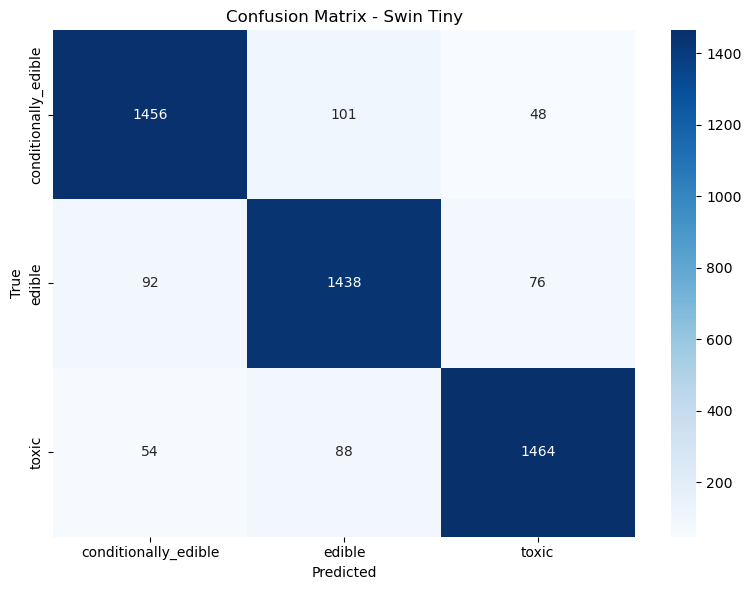


Safety-Critical Recall:


In [ ]:
# ============================================================
# SWIN TINY -- TEST EVALUATION
# ============================================================
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Swin Testing"):
        images, labels = images.to(device), labels.to(device)
        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"\n{'='*60}")
print(f"TEST RESULTS: Swin Tiny")
print(f"{'='*60}")
print(f"Overall Accuracy:  {(all_preds == all_labels).mean():.4f}")
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix - Swin Tiny')
plt.tight_layout()
plt.savefig('swin_tiny_confusion_matrix.png', dpi=150)
plt.show()

print("\nSafety-Critical Recall:")
for cls in ['poisonous', 'deadly']:
    if cls in CLASSES:
        i = CLASSES.index(cls)
        rec = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
        print(f"  {cls:20s} recall = {rec:.4f}  ({cm[i,i]}/{cm[i].sum()})")

In [ ]:
# # ============================================================
# # SWIN TINY -- GRAD-CAM INTERPRETABILITY
# # ============================================================
# # pip install pytorch-grad-cam

# from pytorch_grad_cam import GradCAM
# from pytorch_grad_cam.utils.image import show_cam_on_image
# from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# # Load best model
# model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
# model.eval()

# # For Swin Tiny, target the last normalization layer before the head
# target_layers = [model.layers[-1].blocks[-1].norm2]

# cam = GradCAM(model=model, target_layers=target_layers)

# # Inverse normalization to get displayable images
# inv_normalize = transforms.Normalize(
#     mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
#     std=[1.0/s for s in IMAGENET_STD]
# )

# # --- Visualize correct predictions (sanity check: model looking at mushroom?) ---
# print("=== Grad-CAM on CORRECT predictions ===")
# fig, axes = plt.subplots(4, 4, figsize=(16, 16))

# shown = 0
# with torch.no_grad():
#     for images, labels in test_loader:
#         images, labels = images.to(device), labels.to(device)
#         outputs = model(images)
#         _, predicted = outputs.max(1)
#         correct_mask = predicted.eq(labels)

#         for i in range(images.size(0)):
#             if not correct_mask[i]:
#                 continue
#             if shown >= 16:
#                 break

#             input_tensor = images[i].unsqueeze(0)


#             target_class = labels[i].item()

#             grayscale_cam = cam(input_tensor=input_tensor,
#                                 targets=[ClassifierOutputTarget(target_class)])[0]

#             rgb_img = inv_normalize(images[i].cpu()).permute(1, 2, 0).numpy()
#             rgb_img = np.clip(rgb_img, 0, 1)

#             cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

#             row, col = divmod(shown, 4)
#             axes[row, col].imshow(cam_image)
#             axes[row, col].set_title(f"True: {CLASSES[target_class]}\nPred: {CLASSES[predicted[i].item()]}",
#                                       fontsize=9)
#             axes[row, col].axis('off')
#             shown += 1

#         if shown >= 16:
#             break

# plt.suptitle("Grad-CAM - Correct Predictions (should focus on mushroom body)", fontsize=14)
# plt.tight_layout()
# plt.savefig('swin_tiny_gradcam_correct.png', dpi=150)
# plt.show()

In [ ]:
# # --- Visualize MISCLASSIFIED predictions (where is the model confused?) ---
# print("\n=== Grad-CAM on MISCLASSIFIED predictions ===")
# fig, axes = plt.subplots(4, 4, figsize=(16, 16))

# shown = 0
# with torch.no_grad():
#     for images, labels in test_loader:
#         images, labels = images.to(device), labels.to(device)
#         outputs = model(images)
#         _, predicted = outputs.max(1)
#         wrong_mask = ~predicted.eq(labels)

#         for i in range(images.size(0)):
#             if not wrong_mask[i]:
#                 continue
#             if shown >= 16:
#                 break

#             input_tensor = images[i].unsqueeze(0)
#             true_class = labels[i].item()
#             pred_class = predicted[i].item()

#             grayscale_cam = cam(input_tensor=input_tensor,
#                                 targets=[ClassifierOutputTarget(pred_class)])[0]

#             rgb_img = inv_normalize(images[i].cpu()).permute(1, 2, 0).numpy()
#             rgb_img = np.clip(rgb_img, 0, 1)

#             cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

#             row, col = divmod(shown, 4)
#             axes[row, col].imshow(cam_image)
#             axes[row, col].set_title(f"True: {CLASSES[true_class]}\nPred: {CLASSES[pred_class]}",
#                                       fontsize=9, color='red')
#             axes[row, col].axis('off')
#             shown += 1

#         if shown >= 16:
#             break

# if shown < 16:
#     for idx in range(shown, 16):
#         row, col = divmod(idx, 4)
#         axes[row, col].axis('off')

# plt.suptitle("Grad-CAM - Misclassified (check if model focuses on background/wrong cues)", fontsize=14)
# plt.tight_layout()
# plt.savefig('swin_tiny_gradcam_misclassified.png', dpi=150)
# plt.show()

In [ ]:
# # --- Safety-critical: Grad-CAM on poisonous/deadly samples ---
# print("\n=== Grad-CAM on poisonous/deadly samples ===")
# safety_classes = [c for c in ['poisonous', 'deadly'] if c in CLASSES]
# fig, axes = plt.subplots(len(safety_classes), 5, figsize=(20, 4 * len(safety_classes)))
# if len(safety_classes) == 1:
#     axes = [axes]

# for row_idx, cls_name in enumerate(safety_classes):
#     cls_idx = CLASSES.index(cls_name)
#     shown = 0

#     with torch.no_grad():
#         for images, labels in test_loader:
#             images, labels = images.to(device), labels.to(device)
#             mask = labels.eq(cls_idx)

#             for i in range(images.size(0)):
#                 if not mask[i]:
#                     continue
#                 if shown >= 5:
#                     break

#                 input_tensor = images[i].unsqueeze(0)
#                 outputs = model(input_tensor)
#                 _, pred = outputs.max(1)
#                 pred_class = pred.item()

#                 grayscale_cam = cam(input_tensor=input_tensor,
#                                     targets=[ClassifierOutputTarget(pred_class)])[0]

#                 rgb_img = inv_normalize(images[i].cpu()).permute(1, 2, 0).numpy()
#                 rgb_img = np.clip(rgb_img, 0, 1)

#                 cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

#                 color = 'green' if pred_class == cls_idx else 'red'
#                 axes[row_idx][shown].imshow(cam_image)
#                 axes[row_idx][shown].set_title(
#                     f"True: {cls_name}\nPred: {CLASSES[pred_class]}",
#                     fontsize=9, color=color)
#                 axes[row_idx][shown].axis('off')
#                 shown += 1

#             if shown >= 5:
#                 break

#     for j in range(shown, 5):
#         axes[row_idx][j].axis('off')

# plt.suptitle("Grad-CAM - Safety-Critical Classes (poisonous/deadly)", fontsize=14)
# plt.tight_layout()
# plt.savefig('swin_tiny_gradcam_safety.png', dpi=150)
# plt.show()